In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'Churn_Prediction_data_OperatorX_masked_training.csv')
df.head()

,Mobile_number,CIRCLE_ID,LOC_OG_A2O_MOU,STD_OG_A2O_MOU,LOC_IC_A2O_MOU,LOC_OG_A2O_MOU_BY_TOTAL_OG_MOU,STD_OG_A2O_MOU_BY_TOTAL_OG_MOU,STD_OG_A2C_MOU_BY_TOTAL_OG_MOU,LOC_IC_A2O_MOU_BY_TOTAL_IC_MOU,CTV_CASE_CNT,...,ind_MAX_RECH_AMT_0.2sig,ind_LAST_DAY_RCH_AMT_0.2sig,ind_TOTAL_OG_MOU_0.3sig,ind_TOTAL_RECH_AMT_0.3sig,ind_MAX_RECH_AMT_0.3sig,ind_LAST_DAY_RCH_AMT_0.3sig,ind_TOTAL_OG_MOU_0.75sig,ind_TOTAL_RECH_AMT_0.75sig,ind_MAX_RECH_AMT_0.75sig,ind_LAST_DAY_RCH_AMT_0.75sig
0,7000000041,109,0,0,0,0,0,0,0,4,...,,,,,,,,,,
1,7000000102,109,0,0,0,0,0,0,0,4,...,,,,,,,,,,
2,7000000164,109,0,0,0,0,0,0,0,4,...,,,,,,,,,,
3,7000000379,109,0,0,0,0,0,0,0,4,...,,,,,,,,,,
4,7000000448,109,0,0,0,0,0,0,0,4,...,,,,,,,,,,


In [3]:
print(df.shape)

(121570, 333)


In [41]:
df.columns

Index(['Mobile_number', 'CHURN_INDICATOR', 'ARPU.6', 'ARPU.8', 'ARPU.9',
       'ONNET_MOU.6', 'ONNET_MOU.7', 'ONNET_MOU.8', 'ONNET_MOU.9',
       'OFFNET_MOU.6',
       ...
       'AON', 'AUG_VBC_3G', 'JUL_VBC_3G', 'JUN_VBC_3G', 'N_BREAK', 'N_BREAK_9',
       'DATA_USR_TYP.6', 'DATA_USR_TYP.7', 'DATA_USR_TYP.8', 'DATA_USR_TYP.9'],
      dtype='str', length=103)

### Initial Data Understanding:
#### 1. Identify unique row id, datestamp, target column
#### 2. unique row id to be able to map data from any source. Unique id is important to avoid data explosion
#### 3. datestamp is required to sample OOT (out of time) sample. Data splits - Train, OOS(validation) and OOT(test)

### Step 1: Identify unique identifier for row and target column

In [4]:
df['Mobile_number'].nunique(), df.shape[0]

(121570, 121570)

In [5]:
df['CHURN_INDICATOR'].value_counts(dropna=False, normalize=True)

CHURN_INDICATOR
0    0.904828
1    0.095172
Name: proportion, dtype: float64

In [6]:
for col in df.columns:
    print(col)

Mobile_number
CIRCLE_ID
LOC_OG_A2O_MOU
STD_OG_A2O_MOU
LOC_IC_A2O_MOU
LOC_OG_A2O_MOU_BY_TOTAL_OG_MOU
STD_OG_A2O_MOU_BY_TOTAL_OG_MOU
STD_OG_A2C_MOU_BY_TOTAL_OG_MOU
LOC_IC_A2O_MOU_BY_TOTAL_IC_MOU
CTV_CASE_CNT
CHURN_INDICATOR
ind6
ind7
ind8
ind9
LAST_DATE_OF_MONTH.6
LAST_DATE_OF_MONTH.7
LAST_DATE_OF_MONTH.8
LAST_DATE_OF_MONTH.9
ARPU.6
ARPU.7
ARPU.8
ARPU.9
MEAN_ARPU
ONNET_MOU.6
ONNET_MOU.7
ONNET_MOU.8
ONNET_MOU.9
OFFNET_MOU.6
OFFNET_MOU.7
OFFNET_MOU.8
OFFNET_MOU.9
ROAM_IC_MOU.6
ROAM_IC_MOU.7
ROAM_IC_MOU.8
ROAM_IC_MOU.9
ROAM_OG_MOU.6
ROAM_OG_MOU.7
ROAM_OG_MOU.8
ROAM_OG_MOU.9
LOC_OG_A2A_MOU.6
LOC_OG_A2A_MOU.7
LOC_OG_A2A_MOU.8
LOC_OG_A2A_MOU.9
LOC_OG_A2M_MOU.6
LOC_OG_A2M_MOU.7
LOC_OG_A2M_MOU.8
LOC_OG_A2M_MOU.9
LOC_OG_A2F_MOU.6
LOC_OG_A2F_MOU.7
LOC_OG_A2F_MOU.8
LOC_OG_A2F_MOU.9
LOC_OG_A2C_MOU.6
LOC_OG_A2C_MOU.7
LOC_OG_A2C_MOU.8
LOC_OG_A2C_MOU.9
LOC_OG_MOU.6
LOC_OG_MOU.7
LOC_OG_MOU.8
LOC_OG_MOU.9
STD_OG_A2A_MOU.6
STD_OG_A2A_MOU.7
STD_OG_A2A_MOU.8
STD_OG_A2A_MOU.9
STD_OG_A2M_MOU.6
STD_OG_A2M_MOU.

In [7]:
id_cols = ['CIRCLE_ID']
df.drop(id_cols, axis=1, inplace=True)

In [8]:
df.isnull().sum()

Mobile_number                     0
LOC_OG_A2O_MOU                    0
STD_OG_A2O_MOU                    0
LOC_IC_A2O_MOU                    0
LOC_OG_A2O_MOU_BY_TOTAL_OG_MOU    0
                                 ..
ind_LAST_DAY_RCH_AMT_0.3sig       0
ind_TOTAL_OG_MOU_0.75sig          0
ind_TOTAL_RECH_AMT_0.75sig        0
ind_MAX_RECH_AMT_0.75sig          0
ind_LAST_DAY_RCH_AMT_0.75sig      0
Length: 332, dtype: int64

In [9]:
df['LOC_OG_A2O_MOU'].value_counts(normalize=True)

LOC_OG_A2O_MOU
0    0.990713
     0.009287
Name: proportion, dtype: float64

In [10]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
nulls = pd.DataFrame()
for col in df.columns:
    nulls = pd.concat([nulls, pd.DataFrame({'feature':[col], 'null count':[df[col].isnull().sum()], })])

nulls['Total'] = df.shape[0]
nulls['null%'] = nulls['null count']/nulls['Total']

In [12]:
cols_to_drop = list(nulls[nulls['null%'] > 0.95]['feature'])
len(cols_to_drop)

31

In [13]:
eda = pd.DataFrame()
for col in df.columns:
    eda = pd.concat([eda, pd.DataFrame({'feature':[col], 'null count':[df[col].isnull().sum()], '1st_perc':[df[col].quantile(0.01)], '90th_perc':[df[col].quantile(0.9)]})])

In [14]:
eda['No Variance'] = np.where(eda['1st_perc'] == eda['90th_perc'], 1, 0)

In [15]:
cols_to_drop.extend(list(eda[eda['No Variance'] == 1]['feature']))
cols_to_drop.remove('CHURN_INDICATOR')

In [16]:
len(cols_to_drop)

134

In [17]:
df.drop(cols_to_drop, axis=1, inplace=True)

In [18]:
df.shape

(121570, 211)

In [19]:
df['CHURN_INDICATOR'].unique()

array([1, 0])

## Information value

In [22]:
import pandas as pd
import numpy as np

# Function to calculate IV for a single feature
def calculate_iv(df, feature, target, bins=10):

    temp = df[[feature, target]].copy()

    # Fill missing values first
    if pd.api.types.is_numeric_dtype(temp[feature]):
        temp[feature] = temp[feature].fillna(temp[feature].median())

        try:
            temp[feature] = pd.qcut(temp[feature], q=bins, duplicates='drop')
        except ValueError:
            pass

    else:
        temp[feature] = temp[feature].fillna("MISSING")

    temp[feature] = temp[feature].astype(str)

    grouped = temp.groupby(feature)[target].agg(['count', 'sum'])

    grouped.columns = ['Total', 'Events']
    grouped['NonEvents'] = grouped['Total'] - grouped['Events']

    grouped['EventRate'] = grouped['Events'] / grouped['Events'].sum()
    grouped['NonEventRate'] = grouped['NonEvents'] / grouped['NonEvents'].sum()

    grouped['EventRate'] = grouped['EventRate'].replace(0, 0.0001)
    grouped['NonEventRate'] = grouped['NonEventRate'].replace(0, 0.0001)

    grouped['WOE'] = np.log(grouped['EventRate'] / grouped['NonEventRate'])

    grouped['IV'] = (
        grouped['EventRate'] - grouped['NonEventRate']
    ) * grouped['WOE']

    return grouped['IV'].sum()


# Exclude ID and Target columns
exclude_cols = ['MOBILE_NUMBER', 'CHURN_INDICATOR']
features = [col for col in df.columns if col not in exclude_cols]

# Calculate IV for all features
iv_list = []

for feature in features:
    try:
        iv = calculate_iv(df, feature, 'CHURN_INDICATOR')
        iv_list.append([feature, iv])
    except Exception as e:
        print(f"Skipping {feature}: {e}")

# Create output DataFrame
iv_df = pd.DataFrame(iv_list, columns=['Feature', 'IV'])

# Sort by IV
iv_df = iv_df.sort_values(by='IV', ascending=False).reset_index(drop=True)

In [23]:
iv_df

,Feature,IV
0,Mobile_number,7.178458
1,AON,3.081922
2,N_BREAK_9,2.158552
3,LOC_IC_A2F_MOU.8,0.639560
4,N_BREAK,0.599515
...,...,...
205,ind_TOTAL_RECH_NUM_0.3sig,0.000000
206,ind_ARPU_0.75sig,0.000000
207,ind_TOTAL_IC_MOU_0.75sig,0.000000
208,ind_TOTAL_RECH_NUM_0.75sig,0.000000


In [26]:
cols_to_remove2 = list(iv_df[iv_df['IV'] < 0.02]['Feature'])
len(cols_to_remove2)

75

In [27]:
df.drop(cols_to_remove2, axis=1, inplace=True)

In [28]:
df.shape

(121570, 136)

In [30]:
import pandas as pd
import numpy as np

# Exclude ID and Target columns
exclude_cols = ['MOBILE_NUMBER', 'CHURN_INDICATOR']

# Select only numeric feature columns
feature_df = df.drop(columns=exclude_cols, errors='ignore').select_dtypes(include=np.number)

# Compute correlation matrix
corr_matrix = feature_df.corr(method='pearson')

# Convert to long format
corr_long = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Keep upper triangle only
    .stack()
    .reset_index()
)

# Rename columns
corr_long.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Sort by absolute correlation
corr_long['Abs_Correlation'] = corr_long['Correlation'].abs()

corr_long = (
    corr_long
    .sort_values('Abs_Correlation', ascending=False)
    .reset_index(drop=True)
)

In [31]:
corr_long.head()

,Feature_1,Feature_2,Correlation,Abs_Correlation
0,ARPU.7,TOTAL_RECH_AMT.7,0.959831,0.959831
1,ARPU.6,TOTAL_RECH_AMT.6,0.957672,0.957672
2,ARPU.8,TOTAL_RECH_AMT.8,0.953417,0.953417
3,ARPU.9,TOTAL_RECH_AMT.9,0.946685,0.946685
4,ARPU_3G.6,APRU_2G.6,0.946380,0.946380


In [32]:
corr_long[corr_long['Abs_Correlation'] > 0.8]

,Feature_1,Feature_2,Correlation,Abs_Correlation
0,ARPU.7,TOTAL_RECH_AMT.7,0.959831,0.959831
1,ARPU.6,TOTAL_RECH_AMT.6,0.957672,0.957672
2,ARPU.8,TOTAL_RECH_AMT.8,0.953417,0.953417
3,ARPU.9,TOTAL_RECH_AMT.9,0.946685,0.946685
4,ARPU_3G.6,APRU_2G.6,0.946380,0.946380
5,ARPU_3G.9,APRU_2G.9,0.943759,0.943759
6,ARPU_3G.7,APRU_2G.7,0.942294,0.942294
7,ARPU_3G.8,APRU_2G.8,0.942236,0.942236
8,ARPU.7,MEAN_ARPU,0.912452,0.912452
9,MEAN_ARPU,TOTAL_RECH_AMT.7,0.893816,0.893816


In [35]:
corr_threshold = 0.8

high_corr = corr_long[corr_long['Abs_Correlation'] >= corr_threshold].copy()

iv_dict = dict(zip(iv_df['Feature'], iv_df['IV']))

features_to_drop = set()

for _, row in high_corr.iterrows():

    f1 = row['Feature_1']
    f2 = row['Feature_2']

    # Skip if already removed
    if f1 in features_to_drop or f2 in features_to_drop:
        continue

    iv1 = iv_dict.get(f1, -1)
    iv2 = iv_dict.get(f2, -1)

    if iv1 >= iv2:
        features_to_drop.add(f2)
    else:
        features_to_drop.add(f1)

features_to_drop = sorted(features_to_drop)

In [38]:
len(features_to_drop)

33

In [40]:
df.drop(features_to_drop, axis=1, inplace=True)

In [43]:
df.columns

Index(['Mobile_number', 'CHURN_INDICATOR', 'ARPU.6', 'ARPU.8', 'ARPU.9',
       'ONNET_MOU.6', 'ONNET_MOU.7', 'ONNET_MOU.8', 'ONNET_MOU.9',
       'OFFNET_MOU.6',
       ...
       'AON', 'AUG_VBC_3G', 'JUL_VBC_3G', 'JUN_VBC_3G', 'N_BREAK', 'N_BREAK_9',
       'DATA_USR_TYP.6', 'DATA_USR_TYP.7', 'DATA_USR_TYP.8', 'DATA_USR_TYP.9'],
      dtype='str', length=103)

In [44]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

# ==========================================================
# Parameter: Number of features to select
# ==========================================================
n_features_to_select = 30

# ==========================================================
# Prepare data
# ==========================================================
ID_COL = 'Mobile_number'
TARGET_COL = 'CHURN_INDICATOR'

X = df.drop(columns=[ID_COL, TARGET_COL], errors='ignore')
y = df[TARGET_COL]

# Keep only numeric columns
X = X.select_dtypes(include=np.number)

# Handle missing values
X = X.fillna(X.median())

# ==========================================================
# Random Forest Model
# ==========================================================
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# ==========================================================
# Recursive Feature Elimination
# ==========================================================
rfe = RFE(
    estimator=rf,
    n_features_to_select=n_features_to_select,
    step=1
)

rfe.fit(X, y)

# ==========================================================
# Results
# ==========================================================
rfe_results = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
})

# Selected features
selected_features = (
    rfe_results[rfe_results['Selected']]
    .sort_values('Ranking')
    .reset_index(drop=True)
)

# All features sorted by ranking
rfe_results = (
    rfe_results
    .sort_values(['Ranking', 'Feature'])
    .reset_index(drop=True)
)

print(f"Selected Features: {len(selected_features)}")
print(selected_features)

# List of selected features
selected_feature_list = selected_features['Feature'].tolist()

Selected Features: 30
             Feature  Selected  Ranking
0             ARPU.6      True        1
1             ARPU.8      True        1
2             ARPU.9      True        1
3        ONNET_MOU.9      True        1
4       OFFNET_MOU.7      True        1
5       OFFNET_MOU.8      True        1
6   LOC_OG_A2M_MOU.6      True        1
7   LOC_OG_A2M_MOU.8      True        1
8       LOC_OG_MOU.6      True        1
9       LOC_OG_MOU.8      True        1
10      STD_OG_MOU.9      True        1
11      SPL_OG_MOU.8      True        1
12    TOTAL_OG_MOU.8      True        1
13  LOC_IC_A2M_MOU.6      True        1
14  LOC_IC_A2M_MOU.7      True        1
15  LOC_IC_A2M_MOU.8      True        1
16  LOC_IC_A2M_MOU.9      True        1
17  LOC_IC_A2F_MOU.6      True        1
18  LOC_IC_A2F_MOU.7      True        1
19  LOC_IC_A2F_MOU.8      True        1
20  LOC_IC_A2F_MOU.9      True        1
21      LOC_IC_MOU.6      True        1
22      LOC_IC_MOU.8      True        1
23    TOTAL_IC_MOU

In [45]:
selected_feature_list

['ARPU.6',
 'ARPU.8',
 'ARPU.9',
 'ONNET_MOU.9',
 'OFFNET_MOU.7',
 'OFFNET_MOU.8',
 'LOC_OG_A2M_MOU.6',
 'LOC_OG_A2M_MOU.8',
 'LOC_OG_MOU.6',
 'LOC_OG_MOU.8',
 'STD_OG_MOU.9',
 'SPL_OG_MOU.8',
 'TOTAL_OG_MOU.8',
 'LOC_IC_A2M_MOU.6',
 'LOC_IC_A2M_MOU.7',
 'LOC_IC_A2M_MOU.8',
 'LOC_IC_A2M_MOU.9',
 'LOC_IC_A2F_MOU.6',
 'LOC_IC_A2F_MOU.7',
 'LOC_IC_A2F_MOU.8',
 'LOC_IC_A2F_MOU.9',
 'LOC_IC_MOU.6',
 'LOC_IC_MOU.8',
 'TOTAL_IC_MOU.9',
 'TOTAL_RECH_NUM.6',
 'TOTAL_RECH_NUM.9',
 'MAX_RECH_AMT.9',
 'AON',
 'N_BREAK',
 'N_BREAK_9']

In [46]:
df[selected_feature_list].describe()

,ARPU.6,ARPU.8,ARPU.9,ONNET_MOU.9,OFFNET_MOU.7,OFFNET_MOU.8,LOC_OG_A2M_MOU.6,LOC_OG_A2M_MOU.8,LOC_OG_MOU.6,LOC_OG_MOU.8,...,LOC_IC_A2F_MOU.9,LOC_IC_MOU.6,LOC_IC_MOU.8,TOTAL_IC_MOU.9,TOTAL_RECH_NUM.6,TOTAL_RECH_NUM.9,MAX_RECH_AMT.9,AON,N_BREAK,N_BREAK_9
count,121570.000000,121570.000000,121570.000000,105872.000000,113747.000000,111121.000000,113546.000000,111121.000000,113546.000000,111121.000000,...,105872.000000,113546.000000,111121.000000,121570.000000,121570.000000,121570.000000,121570.000000,121570.000000,39837.000000,39837.000000
mean,273.348343,264.387174,230.117196,124.377925,194.738236,192.526785,72.087068,71.096535,111.868514,110.212098,...,6.536139,130.112561,131.694275,137.833583,7.801489,6.856585,79.762943,382.033067,3.937696,1.538068
std,359.056692,335.448863,322.125217,321.014385,346.246224,344.543976,150.514654,149.393727,243.994453,242.783879,...,33.213004,259.916880,255.423435,280.695761,7.874359,7.893362,106.841170,461.099629,5.017280,2.529967
min,-2424.355000,-1735.231000,-1939.151000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,180.000000,1.000000,0.000000
25%,80.010500,65.382500,28.380000,1.530000,20.440000,18.740000,4.060000,3.680000,7.630000,6.910000,...,0.000000,13.310000,14.740000,6.490000,3.000000,2.000000,10.000000,201.000000,1.000000,0.000000
50%,184.908500,173.698500,143.020000,18.760000,75.590000,75.330000,23.710000,23.240000,37.930000,36.740000,...,0.000000,52.840000,54.760000,54.910000,5.000000,4.000000,50.000000,224.000000,3.000000,1.000000
75%,358.914000,349.320750,313.451000,94.410000,216.435000,216.010000,75.680000,74.690000,115.030000,113.360000,...,2.680000,142.860000,145.810000,154.430000,10.000000,9.000000,130.000000,268.000000,4.000000,3.000000
max,31898.662000,16417.492000,16186.341000,9925.260000,8297.330000,9550.390000,5109.260000,4797.060000,11320.880000,9512.280000,...,3059.240000,9201.090000,10089.760000,12039.740000,179.000000,140.000000,4300.000000,4256.000000,118.000000,54.000000


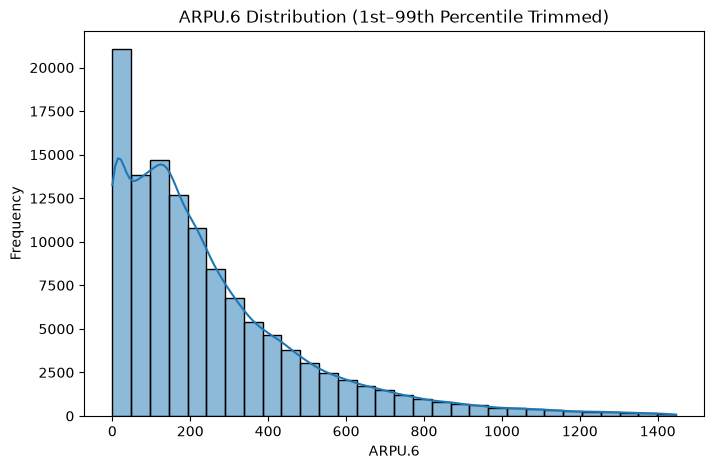

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary trimmed Series (original df remains unchanged)
lower = df['ARPU.6'].quantile(0.01)
upper = df['ARPU.6'].quantile(0.99)

trimmed_arpu = df.loc[
    df['ARPU.6'].between(lower, upper),
    'ARPU.6'
]

plt.figure(figsize=(8, 5))

sns.histplot(trimmed_arpu, bins=30, kde=True)

plt.title('ARPU.6 Distribution (1st–99th Percentile Trimmed)')
plt.xlabel('ARPU.6')
plt.ylabel('Frequency')

plt.show()

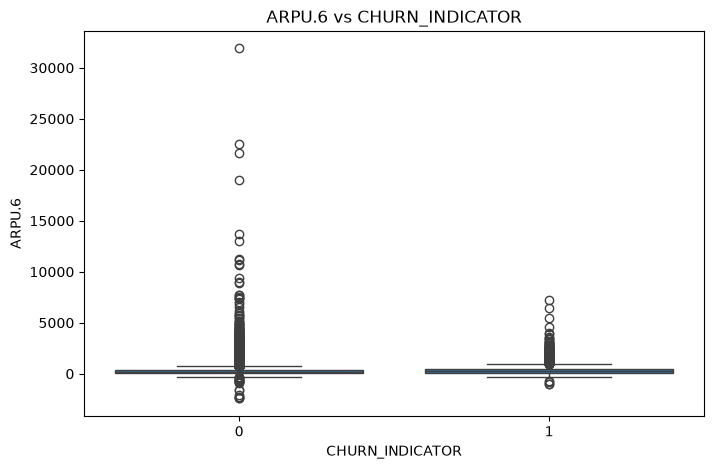

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='CHURN_INDICATOR',
    y='ARPU.6'
)

plt.title('ARPU.6 vs CHURN_INDICATOR')
plt.xlabel('CHURN_INDICATOR')
plt.ylabel('ARPU.6')

plt.show()

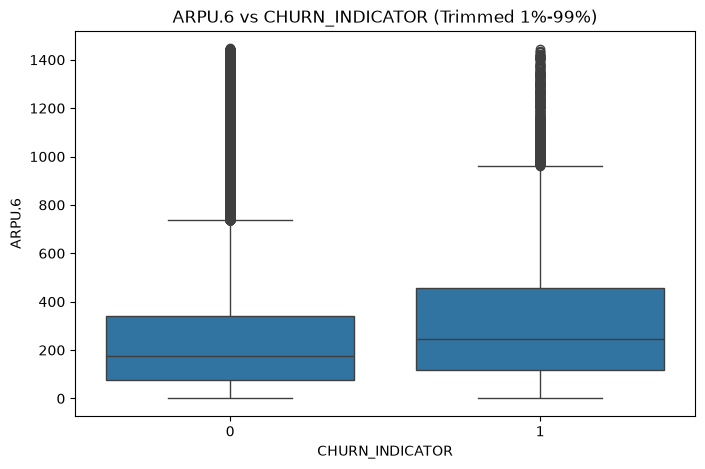

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

lower = df['ARPU.6'].quantile(0.01)
upper = df['ARPU.6'].quantile(0.99)

plot_df = df[df['ARPU.6'].between(lower, upper)]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x='CHURN_INDICATOR',
    y='ARPU.6'
)

plt.title('ARPU.6 vs CHURN_INDICATOR (Trimmed 1%-99%)')
plt.xlabel('CHURN_INDICATOR')
plt.ylabel('ARPU.6')

plt.show()

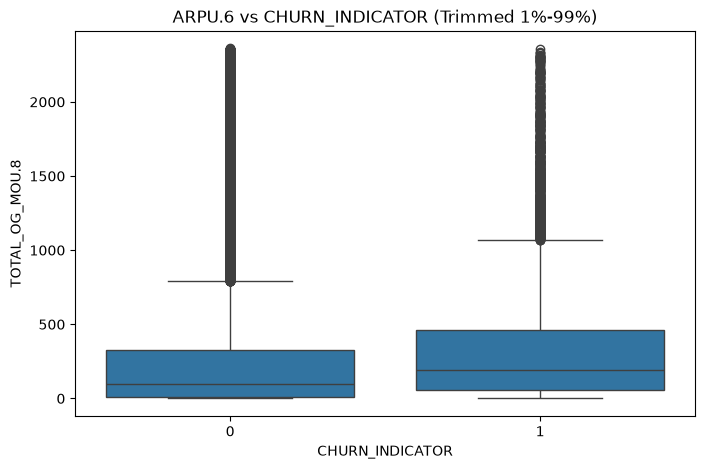

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

lower = df['TOTAL_OG_MOU.8'].quantile(0.01)
upper = df['TOTAL_OG_MOU.8'].quantile(0.99)

plot_df = df[df['TOTAL_OG_MOU.8'].between(lower, upper)]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x='CHURN_INDICATOR',
    y='TOTAL_OG_MOU.8'
)

plt.title('ARPU.6 vs CHURN_INDICATOR (Trimmed 1%-99%)')
plt.xlabel('CHURN_INDICATOR')
plt.ylabel('TOTAL_OG_MOU.8')

plt.show()

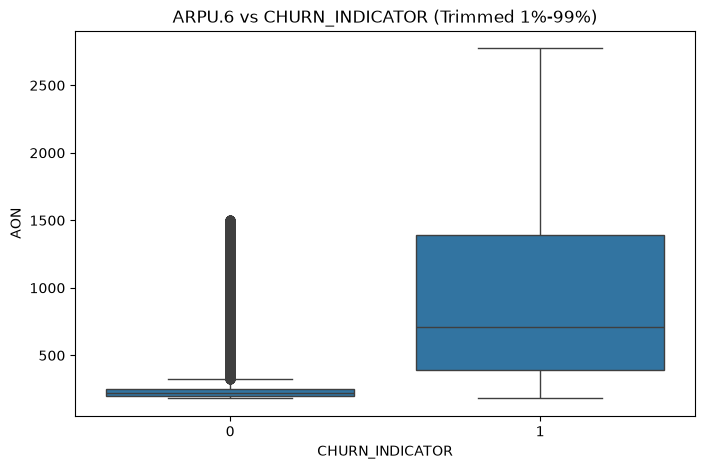

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

lower = df['AON'].quantile(0.01)
upper = df['AON'].quantile(0.99)

plot_df = df[df['AON'].between(lower, upper)]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x='CHURN_INDICATOR',
    y='AON'
)

plt.title('ARPU.6 vs CHURN_INDICATOR (Trimmed 1%-99%)')
plt.xlabel('CHURN_INDICATOR')
plt.ylabel('AON')

plt.show()

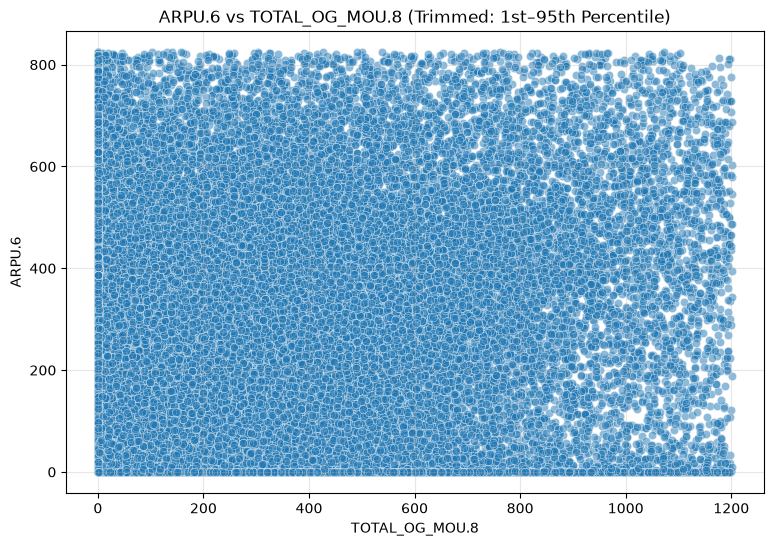

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to plot
x_col = 'TOTAL_OG_MOU.8'
y_col = 'ARPU.6'

# Calculate trimming limits
x_lower = df[x_col].quantile(0.01)
x_upper = df[x_col].quantile(0.95)

y_lower = df[y_col].quantile(0.01)
y_upper = df[y_col].quantile(0.95)

# Create a temporary trimmed DataFrame
plot_df = df[
    df[x_col].between(x_lower, x_upper) &
    df[y_col].between(y_lower, y_upper)
]

# Plot
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=plot_df,
    x=x_col,
    y=y_col,
    alpha=0.5
)

plt.title(f'{y_col} vs {x_col} (Trimmed: 1st–95th Percentile)')
plt.xlabel(x_col)
plt.ylabel(y_col)

plt.grid(alpha=0.3)

plt.show()

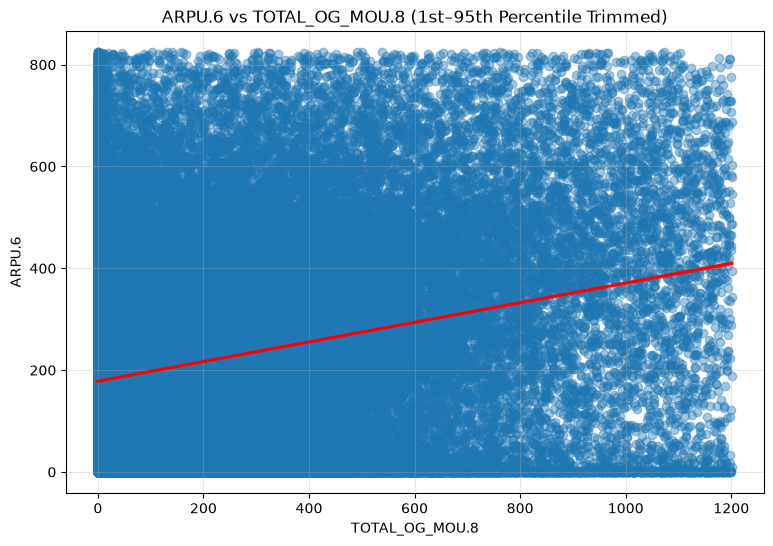

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

sns.regplot(
    data=plot_df,
    x='TOTAL_OG_MOU.8',
    y='ARPU.6',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)

plt.title('ARPU.6 vs TOTAL_OG_MOU.8 (1st–95th Percentile Trimmed)')
plt.grid(alpha=0.3)

plt.show()

In [ ]:
No erratic data - nulls and variance handling
good info value
multicollinearity handled
RFE
Data prepared

In [56]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

# ==========================================================
# Feature List
# ==========================================================

feature_cols = [
    'ARPU.6',
    'ARPU.8',
    'ARPU.9',
    'ONNET_MOU.9',
    'OFFNET_MOU.7',
    'OFFNET_MOU.8',
    'LOC_OG_A2M_MOU.6',
    'LOC_OG_A2M_MOU.8',
    'LOC_OG_MOU.6',
    'LOC_OG_MOU.8',
    'STD_OG_MOU.9',
    'SPL_OG_MOU.8',
    'TOTAL_OG_MOU.8',
    'LOC_IC_A2M_MOU.6',
    'LOC_IC_A2M_MOU.7',
    'LOC_IC_A2M_MOU.8',
    'LOC_IC_A2M_MOU.9',
    'LOC_IC_A2F_MOU.6',
    'LOC_IC_A2F_MOU.7',
    'LOC_IC_A2F_MOU.8',
    'LOC_IC_A2F_MOU.9',
    'LOC_IC_MOU.6',
    'LOC_IC_MOU.8',
    'TOTAL_IC_MOU.9',
    'TOTAL_RECH_NUM.6',
    'TOTAL_RECH_NUM.9',
    'MAX_RECH_AMT.9',
    'AON',
    'N_BREAK',
    'N_BREAK_9'
]

TARGET = "CHURN_INDICATOR"

# ==========================================================
# Prepare Data
# ==========================================================

X = df[feature_cols]
y = df[TARGET]

# ==========================================================
# Train-Test Split (Stratified)
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# Compute Class Weights
# ==========================================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)

# ==========================================================
# Models
# ==========================================================

models = {

    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight=class_weights,
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight=class_weights,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "CatBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function="Logloss",
            eval_metric="F1",
            class_weights=list(class_weights.values()),
            verbose=False,
            random_state=42
        ))
    ])
}

# ==========================================================
# Train & Evaluate
# ==========================================================

results = []

for model_name, model in models.items():

    print("="*70)
    print(model_name)
    print("="*70)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    f1 = f1_score(y_test, pred)

    print(f"\nF1 Score : {f1:.4f}\n")

    print("Classification Report")
    print(classification_report(y_test, pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, pred))

    results.append({
        "Model": model_name,
        "F1 Score": f1
    })

# ==========================================================
# Summary
# ==========================================================

results_df = (
    pd.DataFrame(results)
    .sort_values("F1 Score", ascending=False)
    .reset_index(drop=True)
)

print("\nModel Comparison\n")
print(results_df)

Task was destroyed but it is pending!
task: <Task pending name='Task-326' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Avinash\OneDrive\ドキュメント\Data Science\ash\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-327' coro=<Kernel.shell_main() running at C:\Users\Avinash\OneDrive\ドキュメント\Data Science\ash\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Avinash\OneDrive\ドキュメント\Data Science\ash\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Avinash\AppData\Local\Programs\Python\Python314\Lib\collections\__init__.py:455: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
Task was destroyed but it is pending!
task: <Task pending name='Task-327' coro=<Kernel.shell_main() running at C:\Users\Avinash\OneDrive\ドキュメント\Data Science\ash\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wake

Class Weights: {np.int64(0): np.float64(0.5525909090909091), np.int64(1): np.float64(5.253673292999136)}
Logistic Regression

F1 Score : 0.6371

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.91      0.95     22000
           1       0.51      0.86      0.64      2314

    accuracy                           0.91     24314
   macro avg       0.74      0.89      0.79     24314
weighted avg       0.94      0.91      0.92     24314

Confusion Matrix
[[20055  1945]
 [  323  1991]]
Random Forest

F1 Score : 0.8928

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     22000
           1       0.90      0.89      0.89      2314

    accuracy                           0.98     24314
   macro avg       0.94      0.94      0.94     24314
weighted avg       0.98      0.98      0.98     24314

Confusion Matrix
[[21768   232]
 [  261  2053]]
CatBoost

F1 Score : 0.8612

### Random Forest Model

In [57]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

# ==========================================================
# Random Forest
# ==========================================================

rf = RandomForestClassifier(
    random_state=42,
    class_weight=class_weights,
    n_jobs=-1
)

# ==========================================================
# Small Search Space
# ==========================================================

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [2],
    "max_features": ["sqrt"]
}

# ==========================================================
# Cross Validation
# ==========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ==========================================================
# Random Search
# ==========================================================

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=5,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    refit=True
)

# ==========================================================
# Train
# ==========================================================

random_search.fit(X_train, y_train)

# ==========================================================
# Best Model
# ==========================================================

best_rf = random_search.best_estimator_

print("=" * 60)
print("Best Parameters")
print("=" * 60)
print(random_search.best_params_)

print("\nBest CV F1 Score: {:.4f}".format(random_search.best_score_))

# ==========================================================
# Train Predictions
# ==========================================================

train_pred = best_rf.predict(X_train)

train_f1 = f1_score(y_train, train_pred)

print("\n" + "=" * 60)
print("TRAIN PERFORMANCE")
print("=" * 60)

print(f"F1 Score : {train_f1:.4f}")

print("\nClassification Report")
print(classification_report(y_train, train_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_train, train_pred))

# ==========================================================
# Test Predictions
# ==========================================================

test_pred = best_rf.predict(X_test)

test_f1 = f1_score(y_test, test_pred)

print("\n" + "=" * 60)
print("TEST PERFORMANCE")
print("=" * 60)

print(f"F1 Score : {test_f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, test_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, test_pred))

# ==========================================================
# Summary
# ==========================================================

summary = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "F1 Score": [train_f1, test_f1]
})

print("\n" + "=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
print(summary)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

Best CV F1 Score: 0.8965

TRAIN PERFORMANCE
F1 Score : 0.9730

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     88000
           1       0.95      1.00      0.97      9256

    accuracy                           0.99     97256
   macro avg       0.97      1.00      0.99     97256
weighted avg       1.00      0.99      0.99     97256


Confusion Matrix
[[87487   513]
 [    0  9256]]

TEST PERFORMANCE
F1 Score : 0.8938

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     22000
           1       0.88      0.91      0.89      2314

    accuracy                           0.98     24314
   macro avg       0.93      0.95      0.94     24314
weighted avg       

             Feature  Importance
0                AON    0.307388
1            N_BREAK    0.182573
2          N_BREAK_9    0.174617
3   LOC_IC_A2F_MOU.8    0.032217
4   TOTAL_RECH_NUM.9    0.026994
5   LOC_IC_A2F_MOU.9    0.021518
6   LOC_IC_A2F_MOU.7    0.020230
7   LOC_IC_A2F_MOU.6    0.017663
8             ARPU.9    0.016568
9   LOC_IC_A2M_MOU.9    0.015639
10    TOTAL_IC_MOU.9    0.015200
11      LOC_IC_MOU.8    0.014232
12  LOC_IC_A2M_MOU.8    0.013333
13       ONNET_MOU.9    0.011425
14      LOC_IC_MOU.6    0.010347
15      STD_OG_MOU.9    0.010183
16    MAX_RECH_AMT.9    0.010171
17      LOC_OG_MOU.6    0.009389
18  LOC_IC_A2M_MOU.7    0.009345
19  LOC_IC_A2M_MOU.6    0.008991
20  LOC_OG_A2M_MOU.6    0.008740
21            ARPU.8    0.008567
22      LOC_OG_MOU.8    0.007641
23  LOC_OG_A2M_MOU.8    0.007468
24      SPL_OG_MOU.8    0.007447
25  TOTAL_RECH_NUM.6    0.007306
26            ARPU.6    0.006813
27      OFFNET_MOU.7    0.006335
28      OFFNET_MOU.8    0.005883
29    TOTA

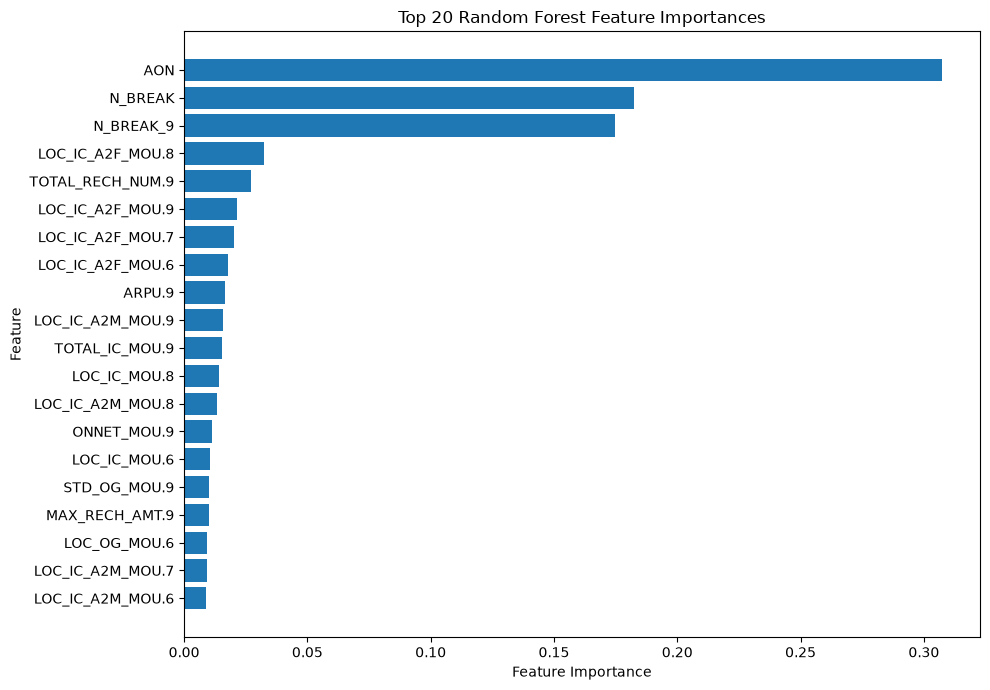

In [59]:
import pandas as pd

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

# Sort descending
feature_importance = (
    feature_importance
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print(feature_importance)

import matplotlib.pyplot as plt

top_n = 20

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance['Feature'][:top_n][::-1],
    feature_importance['Importance'][:top_n][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [60]:
import joblib

# Save the trained model
joblib.dump(best_rf, "random_forest_churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [61]:
!pip install fastapi uvicorn joblib pandas scikit-learn

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------------- ------------------- 1.0/2.1 MB 5.4 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 3.7 MB/s  0:00:00

   ---------------------------------------- 0/9 [typing-inspection]
   ---- ----------------------------------- 1/9 [pydantic-core]
   ---- ----------------------------------- 1/9 [pydantic-core]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   -------- ------------------------------- 2/9 [click]
   --

In [67]:
artifact.feature_importances_

array([0.00681324, 0.00856669, 0.01656845, 0.01142488, 0.00633484,
       0.00588291, 0.00873971, 0.00746843, 0.00938855, 0.00764069,
       0.01018297, 0.00744691, 0.00577609, 0.00899136, 0.0093451 ,
       0.01333297, 0.01563893, 0.01766283, 0.02023047, 0.03221715,
       0.02151844, 0.0103471 , 0.01423206, 0.01519995, 0.00730608,
       0.02699364, 0.01017082, 0.30738806, 0.18257336, 0.1746173 ])

In [71]:
import joblib

artifact = {
    "model": best_rf,
    "features": X_train.columns.tolist()
}

joblib.dump(artifact, "model/random_forest_churn_model.pkl")

['model/random_forest_churn_model.pkl']